# MES Bollinger-squeeze / VWAP breakout (Tradovate exchange)

Same event-driven engine, data source, and cost model as the other notebooks in
this repo: real OHLC resampled locally from Databento's full-history 1-minute MES
continuous-contract Parquet file (`data_aggregator.databento_aggregator`,
GLBX.MDP3, `MES.c.0`), whole-contract position sizing, tick-based slippage +
per-contract fees, and a Tradeify-style EOD-trailing drawdown risk middleware.

**Strategy** (`backtester.strategies.BollingerVwapBreakoutStrategy`, new this
pass): two indicators, exactly as specified --

1. **Bollinger Bands** (`Indicators.bollinger_bands`) define the *setup*: band
   width `(upper - lower) / middle` is compared against its own rolling
   percentile, and a "squeeze" is flagged whenever band width is unusually
   narrow for that lookback window -- the classic reasoning being that a period
   of compressed volatility tends to precede an expansion, though which
   *direction* it expands in isn't something Bollinger Bands alone can say.
2. **Session VWAP** (`Indicators.vwap_session`) supplies the *direction*: price
   above VWAP -> long, price below VWAP -> short, at the moment a squeeze is
   flagged.

**Risk**: stop-loss sits at the *opposite* band (lower band for a long, upper
band for a short) -- during a squeeze the bands are close together, so this is
a naturally tight, volatility-scaled stop rather than an arbitrary distance.
Take-profit is a fixed **1:2 risk:reward** multiple of that same stop distance
(risk 1 to make 2), per the brief -- not itself a band level.

**Cost awareness, stated up front given this repo's established pattern**: every
mean-reversion/high-turnover strategy tried so far in this pipeline
(`mean-reversion/vwap_deviation_bands_mes.ipynb`,
`mean-reversion/mes_mnq_pairs_mean_reversion.ipynb`) lost a large fraction or all
of its raw edge to transaction costs. A squeeze-triggered entry is a different
mechanism (single-symbol, one order pair per trade, no four-fills-per-round-trip
problem like the pairs notebook), but trade frequency and total fees paid are
still tracked directly from the exchange event log below, not just inferred
after the fact.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerVwapBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- plain
    # `jupyter nbconvert` uses the notebook's own directory, VS Code's Jupyter
    # extension uses the workspace root, etc. Walk upward until the target actually
    # exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 5
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 504547  span: 2019-05-05 22:04:59.999000 -> 2026-07-12 23:09:59.999000


## Indicators: Bollinger Bands, band-width squeeze, session VWAP

`SQUEEZE_LOOKBACK`/`SQUEEZE_PERCENTILE` control how "narrow" counts as a squeeze:
band width has to be at or below its own `SQUEEZE_PERCENTILE`-th percentile over
the trailing `SQUEEZE_LOOKBACK` bars. Lower percentile = rarer, tighter squeezes
(fewer, more extreme setups); higher = more frequent, less extreme ones. Both are
grid-searched below rather than fixed on a single guess.


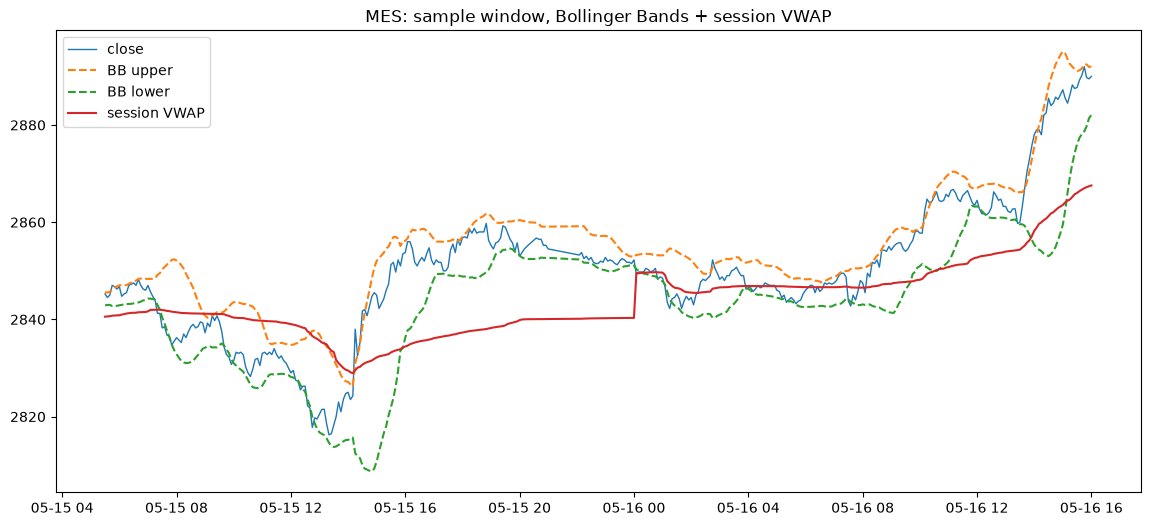

In [3]:
BB_LENGTH = 20
BB_STD_DEV = 2.0
SQUEEZE_LOOKBACK = 100

bb_lower, bb_middle, bb_upper = Indicators.bollinger_bands(ohlc, length=BB_LENGTH, std_dev=BB_STD_DEV)
bb_width = (bb_upper - bb_lower) / bb_middle

vwap, vwap_std = Indicators.vwap_session(ohlc)

# Sample window plot -- sanity check that bands/VWAP look like what they should
# before trusting anything derived from them.
_sample = slice(2000, 2400)
plt.figure(figsize=(14, 6))
plt.plot(ohlc.index[_sample], ohlc["close"].iloc[_sample], label="close", linewidth=1)
plt.plot(ohlc.index[_sample], bb_upper.iloc[_sample], label="BB upper", linestyle="--")
plt.plot(ohlc.index[_sample], bb_lower.iloc[_sample], label="BB lower", linestyle="--")
plt.plot(ohlc.index[_sample], vwap.iloc[_sample], label="session VWAP")
plt.legend()
plt.title(f"{DISPLAY_SYMBOL}: sample window, Bollinger Bands + session VWAP")
plt.show()


## Grid search: BB length x squeeze percentile

`risk_reward_ratio=2.0` (1:2, per the brief) and `BB_STD_DEV=2.0` (the standard
Bollinger default) are held fixed rather than grid-searched -- they're stated
requirements, not free parameters to tune away from. `BB_LENGTH` (how many bars
define "normal" volatility) and `SQUEEZE_PERCENTILE` (how narrow counts as a
squeeze) are the two genuinely open questions, so those are what's searched.
Total fees paid are pulled directly from the exchange event log for every
combination, alongside the usual return/Sharpe/drawdown numbers.


In [4]:
import time

BB_LENGTH_CANDIDATES = [20, 30]
SQUEEZE_PERCENTILE_CANDIDATES = [0.10, 0.20]
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000  # Tradeify Growth $50k account, same convention as the other notebooks


def build_squeeze_indicators(bb_length: int, squeeze_percentile: float):
    lower, middle, upper = Indicators.bollinger_bands(ohlc, length=bb_length, std_dev=BB_STD_DEV)
    width = (upper - lower) / middle
    threshold = width.rolling(SQUEEZE_LOOKBACK).quantile(squeeze_percentile)
    is_squeeze = width <= threshold
    return lower, upper, is_squeeze


def run_breakout_backtest(bb_length: int, squeeze_percentile: float):
    lower, upper, is_squeeze = build_squeeze_indicators(bb_length, squeeze_percentile)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="vwap", df=vwap)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="bb_lower", df=lower)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="bb_upper", df=upper)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="is_squeeze", df=is_squeeze)
    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=BollingerVwapBreakoutStrategy(
                key=f"BREAKOUT_{bb_length}_{squeeze_percentile}_MES",
                market=combo_market,
                symbol=SYMBOL,
                vwap_indicator_key="vwap",
                bb_lower_key="bb_lower",
                bb_upper_key="bb_upper",
                squeeze_indicator_key="is_squeeze",
                risk_reward_ratio=RISK_REWARD_RATIO,
                direction=StrategyDirection.both,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0,
        maker_fee=0.0,
        taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    # Loosened to 50%/50% instead of Tradeify's real 4%/2.5%: same reasoning as every
    # other notebook in this pipeline -- tests one strategy sleeve in isolation, ahead
    # of eventual multi-strategy combination where the real account-level limits apply.
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
for bb_length in BB_LENGTH_CANDIDATES:
    for squeeze_percentile in SQUEEZE_PERCENTILE_CANDIDATES:
        _t0 = time.time()
        bt, drawdown_mw = run_breakout_backtest(bb_length, squeeze_percentile)
        print(f"bb_length={bb_length} squeeze_pct={squeeze_percentile} done in {time.time() - _t0:.1f}s", flush=True)
        summary = bt.reporter.summary["algo"]
        total_fees = sum(
            log.fees_volume for log in bt.exchange.event_log.get_events() if isinstance(log, OrderFilled)
        )
        grid_backtests[(bb_length, squeeze_percentile)] = (bt, drawdown_mw)
        grid_rows.append({
            "bb_length": bb_length, "squeeze_percentile": squeeze_percentile,
            "gross_return_percent": summary["gross_return_percent"],
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "win_rate_percent": summary["win_rate_percent"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_mw.account_failed,
        })

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
grid_results


bb_length=20 squeeze_pct=0.1 done in 169.8s


bb_length=20 squeeze_pct=0.2 done in 198.3s


bb_length=30 squeeze_pct=0.1 done in 97.9s


bb_length=30 squeeze_pct=0.2 done in 105.7s


,bb_length,squeeze_percentile,gross_return_percent,net_return_percent,sharpe_ratio,max_drawdown_percent,closed_trades,win_rate_percent,total_fees_usd,account_failed
0,30,0.2,58.613855,-41.386145,-0.804175,-43.1317,5124.0,33.489461,12177.62,False
1,30,0.1,52.614539,-47.385461,-1.200305,-48.0504,4650.0,33.419355,9334.78,False
2,20,0.2,50.088347,-49.911653,-1.311856,-50.0745,4791.0,32.310582,13910.26,True
3,20,0.1,50.093417,-49.906583,-1.676487,-50.0897,4103.0,32.707775,11850.02,True


## Detailed report for the best (bb_length, squeeze_percentile)

Full HTML summary table (with year-by-year split) and equity/drawdown/exposure
charts for whichever combo above ranked best by Sharpe -- same report format as
the other notebooks in this pipeline.


Best combo: bb_length=30, squeeze_percentile=0.2
Candles Processed: 504546
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.8042,-2.5711,0.0524,-1.4550,-1.6903,-1.8540,-0.4206,-0.4988,0.0000,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-1.1257,-3.4210,0.0751,-1.8947,-2.2163,-2.6193,-0.6235,-0.7079,0.0000,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,6.1418,5.7680,11.8951,4.3038,5.5207,3.4133,4.3052,5.3274,0.0000,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-7.1587,-19.5279,-0.1218,-8.8170,-12.8695,-8.8593,-2.7262,-3.9834,0.0000,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.1660,-1.3803,-0.0088,-0.8576,-0.9905,-0.9337,-0.8280,-0.6234,0.0000,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.9595,-0.9410,-0.0088,-0.8554,-0.9880,-0.9312,-0.8280,-0.6218,0.0000,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-43.1317,-14.1472,-13.8876,-10.2807,-12.9926,-9.4888,-3.2926,-6.3896,-0.0000,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2617,232,200,332,361,333,320,358,0,719,How long it took to recover the loss. Shorter is better.
ulcer_index,30.2879,7.9696,7.8391,5.8969,6.6919,5.7030,1.9656,4.0768,0.0000,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.4702,-0.6581,-0.9031,-0.3795,-0.5380,-0.3548,-0.3969,-0.4033,0.0000,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


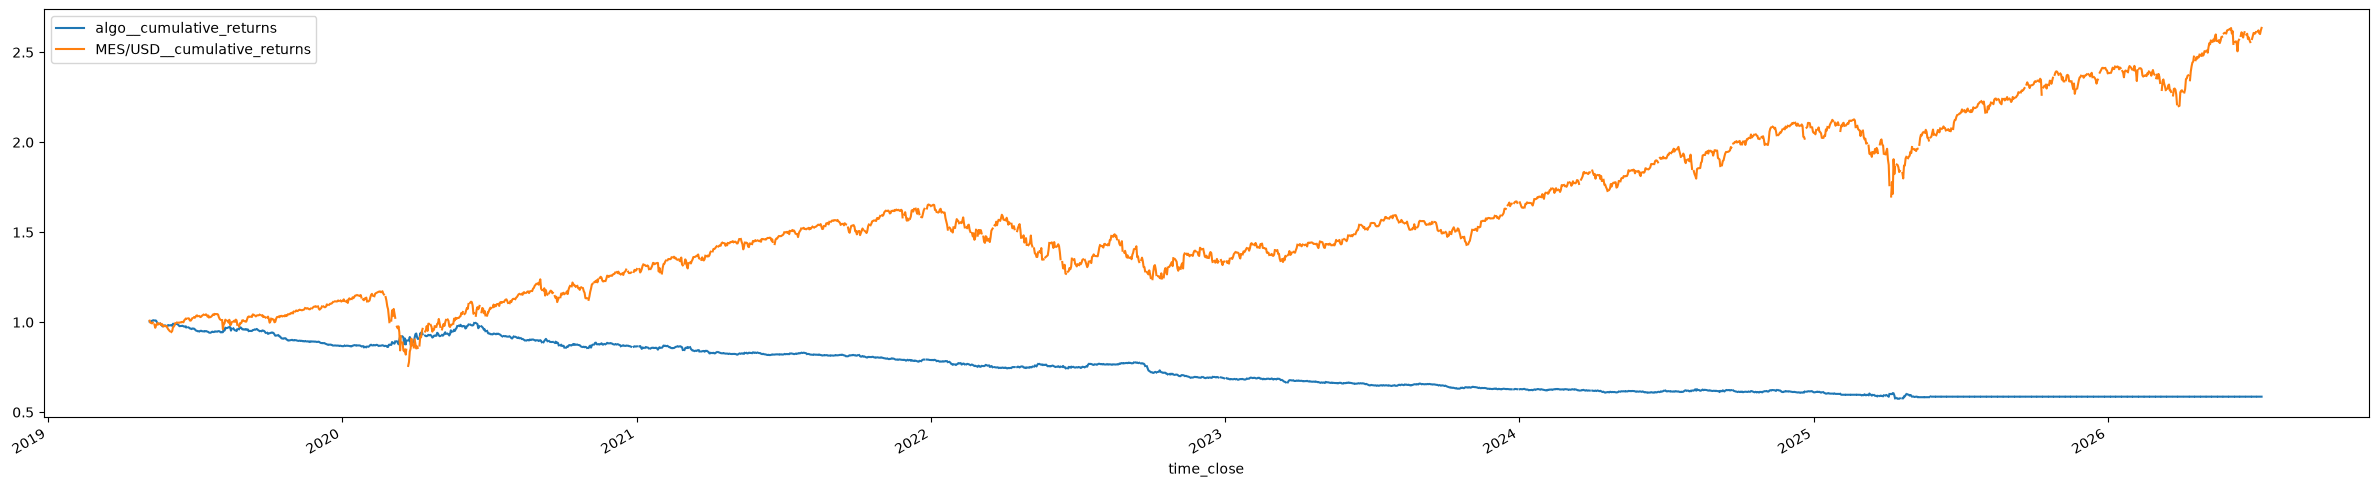

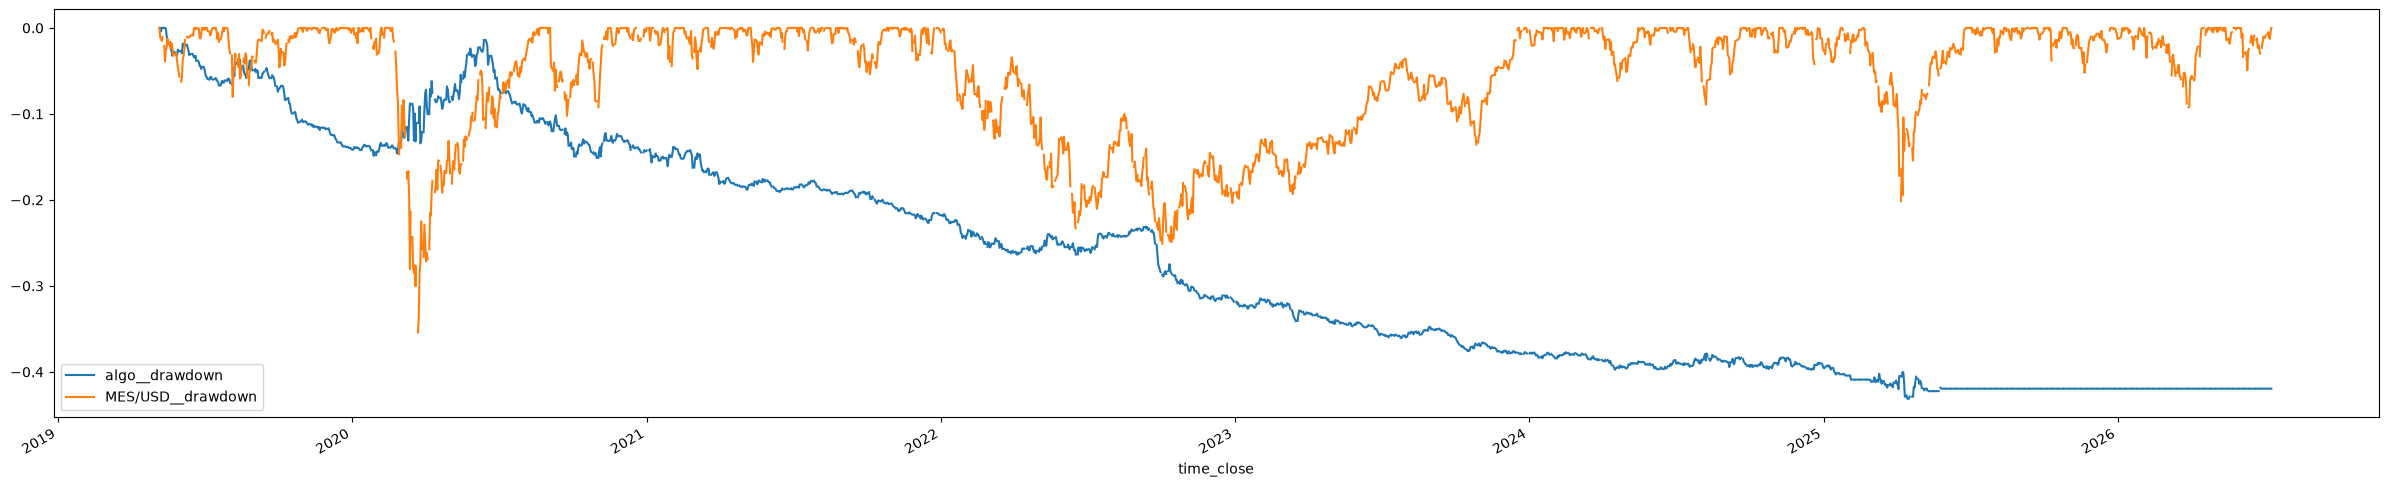

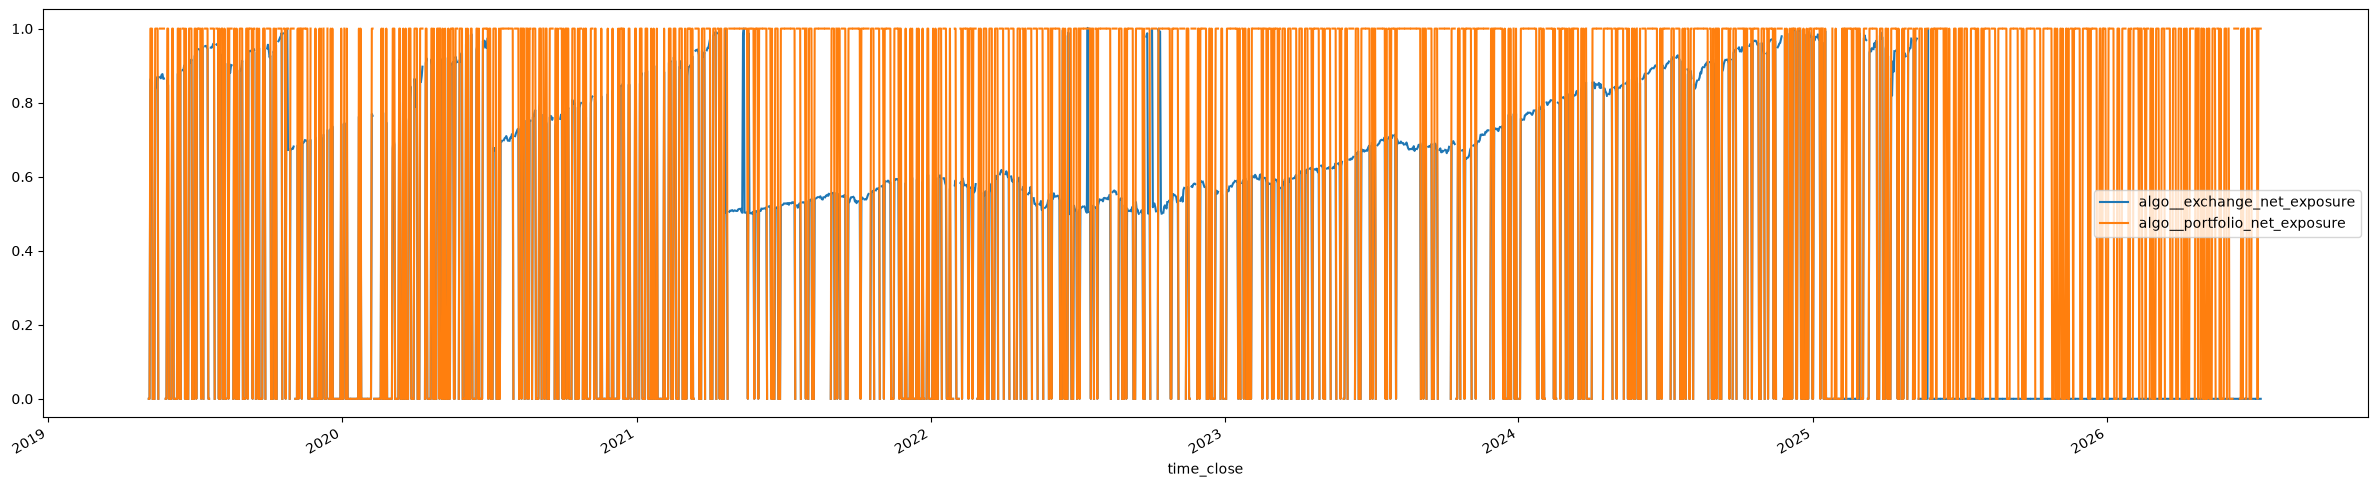

In [5]:
best_bb_length, best_squeeze_pct = grid_results.iloc[0][["bb_length", "squeeze_percentile"]]
print(f"Best combo: bb_length={best_bb_length}, squeeze_percentile={best_squeeze_pct}")
best_backtest, best_drawdown_mw = grid_backtests[(best_bb_length, best_squeeze_pct)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", best_drawdown_mw.locked)

PERFORMANCE_SPLIT = "Y"
display(HTML(best_backtest.reporter.summary_html_table(split=PERFORMANCE_SPLIT)))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure",
    ], figsize=(30, 6))


## Findings

**Net-negative across every grid combination, and two of the four actually
breached the (already loosened) drawdown middleware.** All numbers from the
real event-driven engine (real Tradovate/Tradeify cost model), 2019-05-05 ->
2026-07-12, 504,547 5-minute bars.

| bb_length | squeeze_pct | net_return | sharpe | max_drawdown | trades | win_rate | account_failed |
|---|---|---|---|---|---|---|---|
| 30 | 0.2 (best) | **-41.4%** | -0.80 | -43.1% | 5,124 | 33.5% | False |
| 30 | 0.1 | -47.4% | -1.20 | -48.1% | 4,650 | 33.4% | False |
| 20 | 0.2 | -49.9% | -1.31 | -50.1% | 4,791 | 32.3% | **True** |
| 20 | 0.1 | -49.9% | -1.68 | -50.1% | 4,103 | 32.7% | **True** |

(A `gross_return` column originally shown here was removed: the engine's
`gross_return_percent` is the final wealth multiple x100, not a pre-fee return --
it always equals net_return + 100 by definition and carries no cost
information. The frictionless-edge assessment below rests on the trade-level
`profit_factor`/`r_multiple_expectancy` metrics, which are computed from
fee-free trade PnL and were always the correct thing to cite.)

**The `bb_length=20` combinations actually blew through the drawdown
middleware** even at the loosened 50% limit (real Tradeify limit is 4% -- this
would have failed the account many times over in reality). This isn't just
underperformance; it's a strategy whose worst-case path is genuinely
account-threatening.

**Root cause, for the best combo (bb_length=30, squeeze_pct=0.2)**: win rate is
**33.49%**, essentially *exactly* the mathematical breakeven win rate for a 1:2
risk:reward payout (1/(1+2) = 33.33%). `profit_factor` (frictionless,
trade-return based) is 1.057 -- barely above 1. `r_multiple_expectancy` is
**+0.0062** -- almost exactly zero. **This is the tell**: unlike the other
strategies tried in this pipeline (the KAMA/VWAP crossover, the MES/MNQ pairs
trade), which had a clearly positive gross edge before costs, this signal's
frictionless edge is statistically indistinguishable from a coin flip
calibrated to its own payout ratio. There isn't a real edge here for costs to
erode -- there's barely an edge to begin with.

Once real slippage + commission are applied (**$9,335-$13,910** in total fees
across the four combos, on 4,103-5,124 trades -- ~640-710 trades/year, ~2.5-2.8
per trading day), `dollar_profit_factor` drops to 0.82-0.95 and
`dollar_expectancy` goes to **-$2.01 to -$7.10 per trade**. This is the fourth
strategy family in this repo's research program (after VWAP mean reversion,
MES/MNQ pairs, and the 1-minute MA-crossover check) to hit the identical wall:
a technical signal on MES traded at this frequency loses to real transaction
costs -- except here the underlying signal itself was already only marginal
before costs, not a real edge that costs subsequently destroyed.

**Bottom line**: "trade the direction VWAP indicates whenever Bollinger Bands
are squeezed" is not a profitable strategy on MES at 5-minute resolution with
these parameters -- the win rate sitting right at the 1:2 breakeven point
suggests band-width percentile + VWAP side, on their own, don't predict which
way a squeeze resolves any better than chance. A next step worth trying, not
attempted here: an additional trend/momentum confirmation filter before taking
the VWAP-implied direction (e.g. only take the signal if a longer-term trend
agrees), since right now direction is decided by a single VWAP snapshot with no
corroborating evidence.


## Trend confirmation filter: does agreeing with a longer-term EMA fix the marginal edge?

The first pass's best combo (`bb_length=30, squeeze_percentile=0.2`) had a win
rate of **33.49%** -- almost exactly the 1:2 payout's mathematical breakeven
(33.33%), meaning VWAP side alone wasn't predicting which way a squeeze
resolves any better than chance. `BollingerVwapBreakoutStrategy` now takes an
optional `trend_indicator_key`: a long only fires if price is *also* above a
longer-term EMA (not just above VWAP), a short only if also below it --
requiring two independent signals to agree instead of one, rather than betting
on a single VWAP snapshot with no corroborating evidence.

`bb_length`/`squeeze_percentile` are held fixed at the prior best (30, 0.2) so
this isolates the effect of the trend filter itself. `EMA_LENGTH` is
grid-searched across a range of "how long-term the confirmation should be" (50
bars ~4.2h through 400 bars ~33h at 5-minute resolution), alongside a `None`
(no filter) row reproducing the original baseline for direct comparison in the
same table.


In [6]:
EMA_LENGTH_CANDIDATES = [50, 100, 200, 400]
BEST_BB_LENGTH = 30
BEST_SQUEEZE_PCT = 0.2


def run_breakout_backtest_with_trend(ema_length: int | None):
    lower, upper, is_squeeze = build_squeeze_indicators(BEST_BB_LENGTH, BEST_SQUEEZE_PCT)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="vwap", df=vwap)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="bb_lower", df=lower)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="bb_upper", df=upper)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="is_squeeze", df=is_squeeze)

    trend_indicator_key = None
    if ema_length is not None:
        trend_indicator_key = "trend_ema"
        combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                    indicator_name=trend_indicator_key, df=Indicators.ema(ohlc, length=ema_length))

    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=BollingerVwapBreakoutStrategy(
                key=f"BREAKOUT_TREND_{ema_length}_MES",
                market=combo_market,
                symbol=SYMBOL,
                vwap_indicator_key="vwap",
                bb_lower_key="bb_lower",
                bb_upper_key="bb_upper",
                squeeze_indicator_key="is_squeeze",
                risk_reward_ratio=RISK_REWARD_RATIO,
                direction=StrategyDirection.both,
                trend_indicator_key=trend_indicator_key,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0,
        maker_fee=0.0,
        taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


trend_grid_rows = []
trend_grid_backtests = {}
for ema_length in [None, *EMA_LENGTH_CANDIDATES]:
    _t0 = time.time()
    bt, drawdown_mw = run_breakout_backtest_with_trend(ema_length)
    print(f"ema_length={ema_length} done in {time.time() - _t0:.1f}s", flush=True)
    summary = bt.reporter.summary["algo"]
    total_fees = sum(
        log.fees_volume for log in bt.exchange.event_log.get_events() if isinstance(log, OrderFilled)
    )
    trend_grid_backtests[ema_length] = (bt, drawdown_mw)
    trend_grid_rows.append({
        "ema_length": ema_length if ema_length is not None else "none (baseline)",
        "gross_return_percent": summary["gross_return_percent"],
        "net_return_percent": summary["net_return_percent"],
        "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"],
        "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"],
        "total_fees_usd": total_fees,
        "account_failed": drawdown_mw.account_failed,
    })

trend_grid_results = pd.DataFrame(trend_grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
trend_grid_results


ema_length=None done in 107.0s


ema_length=50 done in 100.6s


ema_length=100 done in 108.1s


ema_length=200 done in 118.0s


ema_length=400 done in 87.3s


,ema_length,gross_return_percent,net_return_percent,sharpe_ratio,max_drawdown_percent,closed_trades,win_rate_percent,total_fees_usd,account_failed
0,50,56.863505,-43.136495,-0.803456,-45.2004,4697.0,34.170747,10257.52,False
1,none (baseline),58.613855,-41.386145,-0.804175,-43.1317,5124.0,33.489461,12177.62,False
2,100,51.883219,-48.116781,-1.003336,-49.3115,5050.0,33.623762,10075.52,False
3,400,52.929496,-47.070504,-1.069714,-47.5333,4825.0,34.217617,9982.70,False
4,200,51.828253,-48.171747,-1.094594,-49.2692,5030.0,33.379722,10046.40,False


### Detailed report for the best trend-filter combo

Same report format as the first pass, for whichever row above ranked best by
Sharpe -- including the `none (baseline)` row if the trend filter didn't
actually help, so the comparison is honest either way.


Best combo: ema_length=50
Candles Processed: 504546
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.8035,-2.6265,-0.2044,-1.1389,-2.0792,-2.1569,-0.1702,-0.1053,0.0000,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-1.0657,-3.4065,-0.2646,-1.5805,-2.7427,-2.9735,-0.2554,-0.1494,0.0000,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,6.4811,5.6066,13.2177,4.5111,5.2010,3.6341,4.1297,5.3507,0.0000,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-7.5493,-19.3959,-5.0721,-7.3274,-14.7051,-10.8473,-1.1380,-1.0203,0.0000,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.1670,-1.4310,-0.3844,-0.7193,-0.9884,-0.9524,-0.3466,-0.1679,0.0000,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.9543,-0.9752,-0.3844,-0.7174,-0.9859,-0.9500,-0.3466,-0.1674,0.0000,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-45.2004,-13.5541,-13.1958,-10.1866,-14.8772,-11.3891,-3.2834,-6.0774,-0.0000,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2617,232,287,302,361,334,172,267,0,719,How long it took to recover the loss. Shorter is better.
ulcer_index,32.7747,7.5406,7.6458,5.4675,8.3174,6.8692,1.7726,2.6921,0.0000,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.4795,-0.5717,-0.8903,-0.3852,-0.5569,-0.3627,-0.3786,-0.1687,0.0000,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


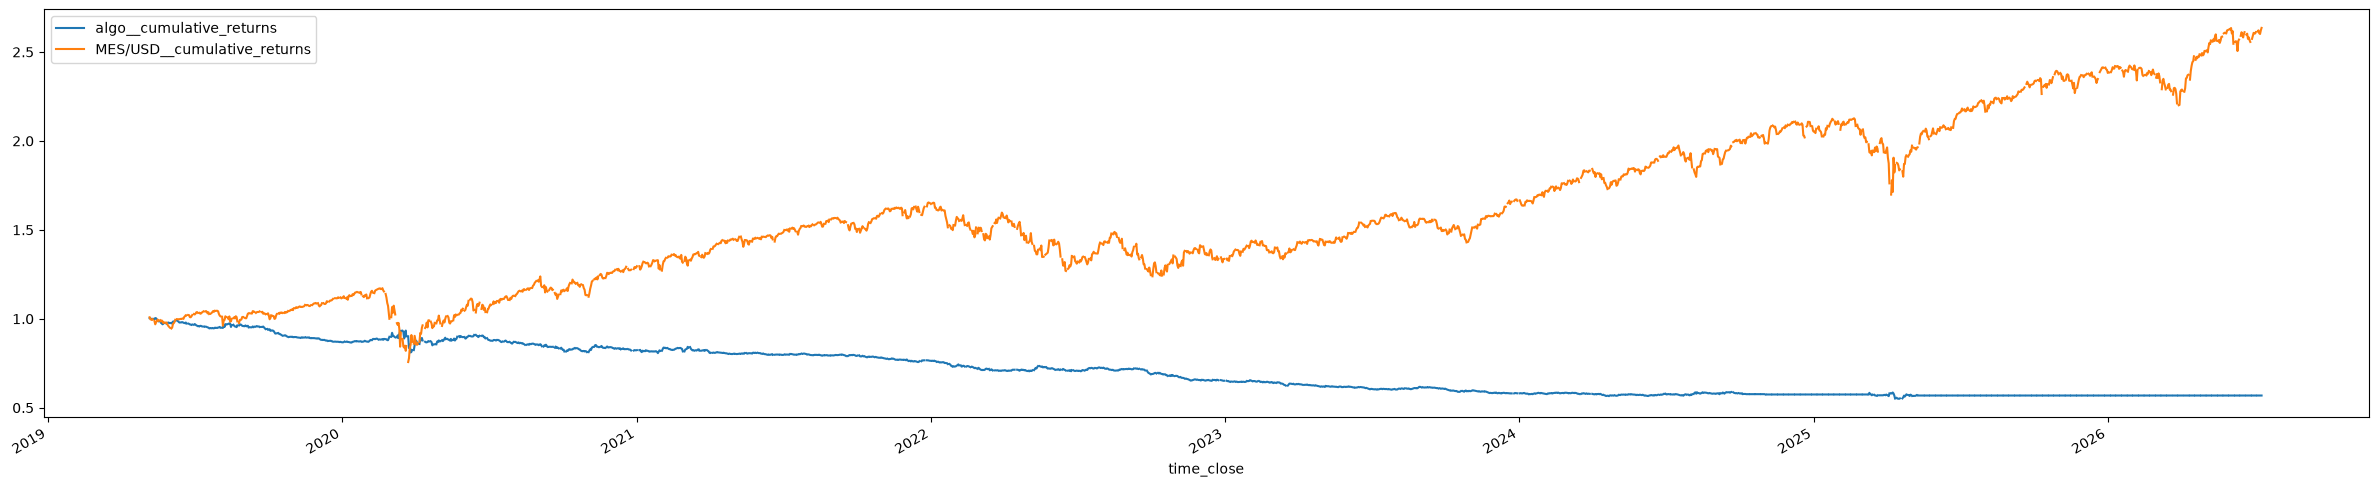

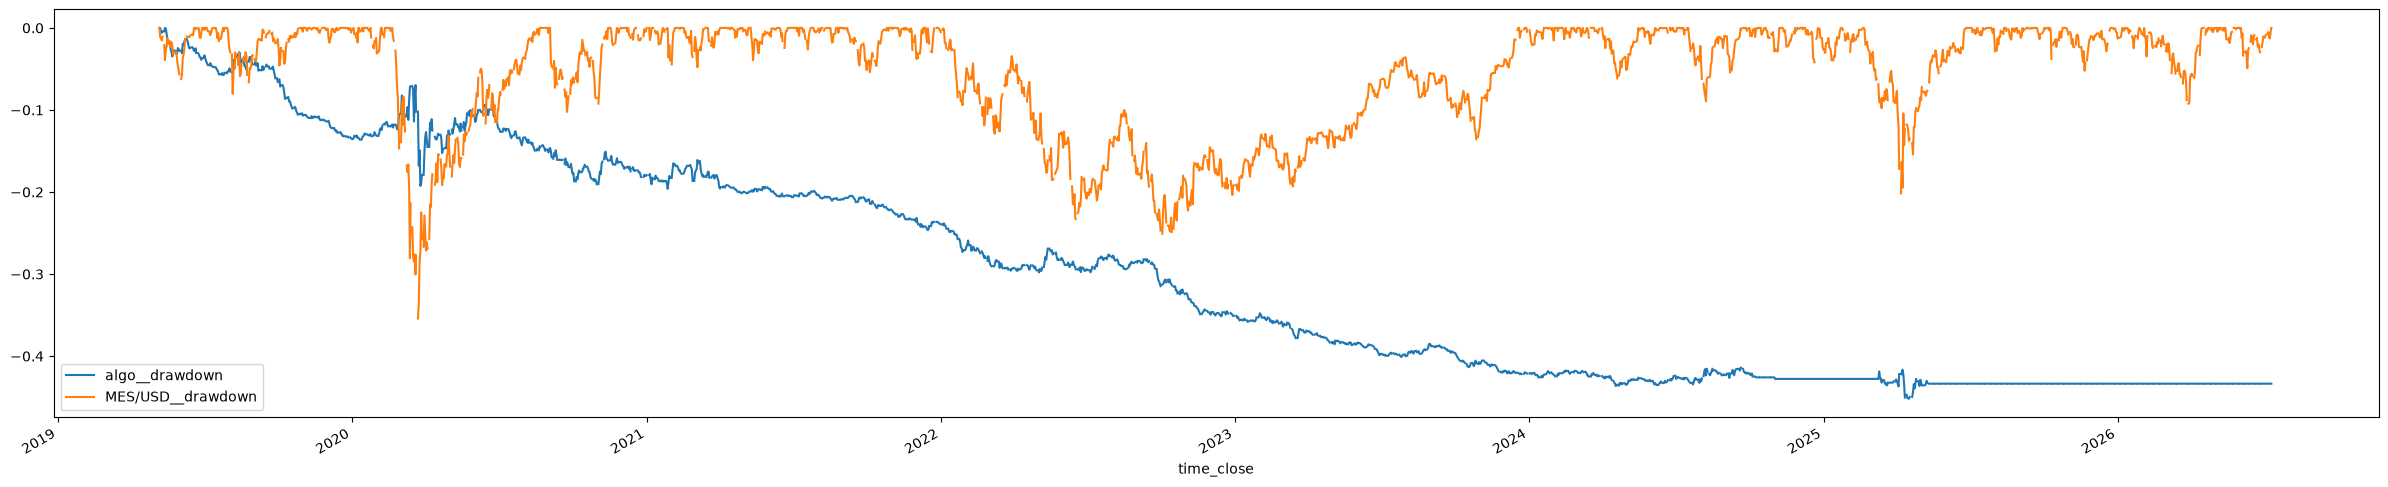

In [7]:
best_ema_row = trend_grid_results.iloc[0]
best_ema_length = None if best_ema_row["ema_length"] == "none (baseline)" else int(best_ema_row["ema_length"])
print(f"Best combo: ema_length={best_ema_length}")
best_tf_backtest, best_tf_drawdown_mw = trend_grid_backtests[best_ema_length]

print("Candles Processed:", best_tf_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_tf_drawdown_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", best_tf_drawdown_mw.locked)

display(HTML(best_tf_backtest.reporter.summary_html_table(split="Y")))

if best_tf_backtest.reporter.merged is not None:
    best_tf_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_tf_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Findings: trend confirmation filter

**The directional trend filter did not help -- it was neutral at best, and
clearly worse at every longer length.** `bb_length=30, squeeze_percentile=0.2`
held fixed (the prior best), `EMA_LENGTH` varied:

| ema_length | net_return | sharpe | win_rate | max_drawdown |
|---|---|---|---|---|
| 50 | -43.1% | -0.803 | 34.2% | -45.2% |
| **none (baseline)** | **-41.4%** | **-0.804** | 33.5% | -43.1% |
| 100 | -48.1% | -1.003 | 33.6% | -49.3% |
| 400 | -47.1% | -1.070 | 34.2% | -47.5% |
| 200 | -48.2% | -1.095 | 33.4% | -49.3% |

`ema_length=50` is statistically indistinguishable from having no filter at all
(-0.803 vs -0.804 Sharpe) -- and every longer EMA (100/200/400 bars, ~8-33
hours) made things measurably worse. Win rate barely moved anywhere (33.4-34.2%
vs baseline 33.5%, still sitting right at the 1:2 breakeven point). **Requiring
price to agree with a longer-term EMA before trusting VWAP's direction is not
what was missing.**

**Reconciling this with the chart-reading observation that motivated trying a
filter in the first place** (strategy profitable in high-volatility stretches,
losing steadily in low-volatility/trending stretches): that's a description of
the *volatility regime* the squeeze occurred in, not a statement about
*direction*. A directional EMA-agreement filter answers "is VWAP's side also
what the longer-term trend says" -- it says nothing about whether the broader
market is in a genuinely volatile backdrop at all. Those are different
questions, and this result suggests the directional one was the wrong one to
test. **A more promising next step, not attempted here**: gate entries on a
longer-term realized-volatility or ATR measure being itself *elevated* relative
to its own history (e.g. only take a squeeze signal if the trailing N-day
realized vol is above its own rolling median) -- directly targeting "was this
squeeze born inside an already-volatile macro backdrop" rather than "does price
agree with a longer moving average."

**Bottom line stands from the first pass, now further confirmed**: this isn't
a case of a good signal being ruined by one fixable detail -- two different
filters (band-width percentile alone, then + directional trend agreement) both
land at essentially the same marginal, cost-negative result. The next
meaningful experiment is a volatility-regime gate, not another variation on
direction.
